In [2]:
import os

In [3]:
from dotenv import load_dotenv
load_dotenv()

True

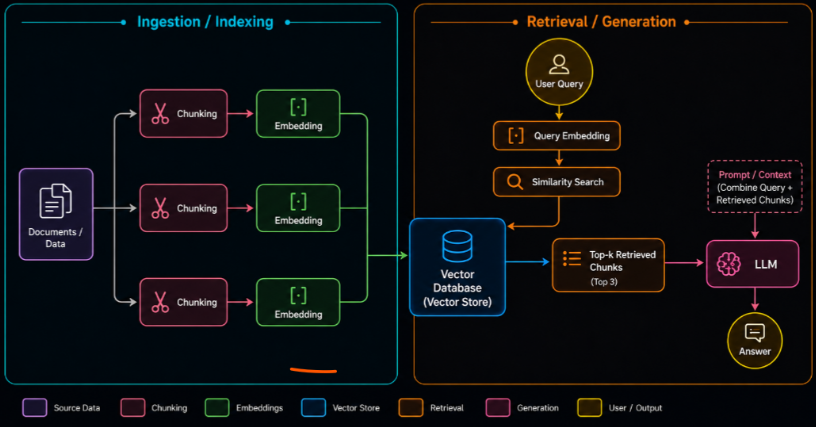

In [4]:
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [5]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [6]:
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [7]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

In [8]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

In [9]:
embeddings.embed_query("Hello world")

[-0.02342152,
 0.01676572,
 0.009261323,
 -0.06383,
 -0.0026262768,
 0.0010187156,
 -0.01125684,
 0.0130036585,
 0.008751671,
 0.0012745215,
 -0.0007880878,
 -0.019086141,
 0.030971918,
 0.044264916,
 0.11137619,
 0.018025596,
 -0.0031383373,
 -0.0130702155,
 0.0054121013,
 -0.009036983,
 0.009904047,
 -0.010718052,
 0.012551899,
 0.011420718,
 -0.03375867,
 0.008877066,
 0.027795823,
 0.0037452083,
 0.029841818,
 0.019861836,
 0.018075233,
 -0.007178086,
 -0.02497957,
 0.011720823,
 -0.0073324037,
 0.0068515264,
 0.011618152,
 0.004278904,
 -0.0099426275,
 -0.009696086,
 -0.0037028084,
 0.006349137,
 -0.012098703,
 -0.015629271,
 -0.022799378,
 -0.012305125,
 -0.01497548,
 -0.006503783,
 -0.005624279,
 0.020265369,
 -0.029982245,
 -0.008486281,
 -0.0050998786,
 -0.14985937,
 -0.017222198,
 0.011674307,
 -0.014542328,
 0.02246327,
 -0.009126675,
 -0.018621653,
 -0.004780002,
 0.0020153068,
 -0.0133157885,
 -0.006439805,
 0.0008783784,
 -0.023549458,
 -0.008333907,
 0.01863065,
 -0.0190

In [ ]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

embeddings.embed_query

In [10]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")

In [11]:
llm.invoke("Hi, How are you?").content[0]["text"]

"I'm doing great, thank you for asking! How are you doing today? Is there anything I can help you with?"

#### It is simple AI Assistant without RAG Pipeline

In [12]:
while True:
    user_input = input("You: ")

    if user_input.lower() in ["exit", "quit"]:
        print("Exiting the chat. Goodbye!")
        break

    response = llm.invoke(user_input).content[0]["text"]
    print(f"AI: {response}")

AI: Hello! How can I help you today?
AI: Ruturaj Gaikwad has carved a distinct niche for himself in Indian cricket, often drawing comparisons to legends like Virat Kohli and Kane Williamson due to his batting style and temperament.

Here is how Ruturaj Gaikwad stands out from the typical modern-day T20/ODI batter:

### 1. The "Pure" Technique in an Era of Power
While most modern openers focus on "clearing the ropes" from ball one, Gaikwad relies on **classical cricketing shots**. He rarely resorts to "muscling" the ball. Instead, he uses the pace of the bowler, impeccable timing, and perfect balance. He plays the ball late and finds gaps with surgical precision, which makes his batting look effortless and aesthetically pleasing.

### 2. Exceptional Ability to "Play Through the Innings"
Gaikwad is one of the few contemporary players who still follows the traditional "anchor" philosophy in T20s. He possesses the rare skill of:
*   **Starting slow and accelerating exponentially:** He ofte

In [13]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader

In [14]:
from langchain_community.document_loaders import WebBaseLoader

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [15]:
from langchain_community.document_loaders import PyPDFLoader

In [17]:
file_path = "C:\\Users\\Amanm\\Desktop\\Gen-AI Learning\\RAG-Pipeline-End-To-End\\deepseek-v4-2026.pdf"

In [18]:
pages = PyPDFLoader(file_path).load()

In [19]:
len(pages)

58

In [20]:
pages

[Document(metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:a6404ea)', 'creationdate': '', 'author': 'DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao Wu; Bowei Zhang; Chaofan Lin; Chen Dong; Chenchen Ling; Chengda Lu; Chenggang Zhao; Chengqi Deng; Chengyu Hou; Chenhao Xu; Chenze Shao; Chong Ruan; Conner Sun; Damai Dai; Daya Guo; Dejian Yang; Deli Chen; Donghao Li; Dongjie Ji; Erhang Li; Fang Wei; Fangyun Lin; Fangzhou Yuan; Feiyu Xia; Fucong Dai; Guangbo Hao; Guanting Chen; Guoai Cao; Guolai Meng; Guowei Li; Han Yu; Han Zhang; Hanwei Xu; Hao Li; Haofen Liang; Haoling Zhang; Haoming Luo; Haoran Wei; Haotian Yuan; Haowei Zhang; Haowen Luo; Haoyu Chen; Haozhe Ji; Hengqing Zhang; Honghui Ding; Hongxuan Tang; Huanqi Cao; Huazuo Gao; Hui Qu; Hui Zeng; J Yang; JQ Zhu; Jia Luo; Jia Song; Jia Yu; Jialiang Huang; Jialu Cai; Jian Liang; Jiangting Zhou; Jiasheng Ye; Jiashi Li; Jiaxin Xu; Jiewen Hu; Jieyu Yang; Jin Chen; Jin Yan; Jingchang Ch

In [21]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [22]:
chunker = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=400)

In [23]:
chunked_data = chunker.split_documents(pages)

In [24]:
len(chunked_data)

283

In [25]:
chunked_data

[Document(metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:a6404ea)', 'creationdate': '', 'author': 'DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao Wu; Bowei Zhang; Chaofan Lin; Chen Dong; Chenchen Ling; Chengda Lu; Chenggang Zhao; Chengqi Deng; Chengyu Hou; Chenhao Xu; Chenze Shao; Chong Ruan; Conner Sun; Damai Dai; Daya Guo; Dejian Yang; Deli Chen; Donghao Li; Dongjie Ji; Erhang Li; Fang Wei; Fangyun Lin; Fangzhou Yuan; Feiyu Xia; Fucong Dai; Guangbo Hao; Guanting Chen; Guoai Cao; Guolai Meng; Guowei Li; Han Yu; Han Zhang; Hanwei Xu; Hao Li; Haofen Liang; Haoling Zhang; Haoming Luo; Haoran Wei; Haotian Yuan; Haowei Zhang; Haowen Luo; Haoyu Chen; Haozhe Ji; Hengqing Zhang; Honghui Ding; Hongxuan Tang; Huanqi Cao; Huazuo Gao; Hui Qu; Hui Zeng; J Yang; JQ Zhu; Jia Luo; Jia Song; Jia Yu; Jialiang Huang; Jialu Cai; Jian Liang; Jiangting Zhou; Jiasheng Ye; Jiashi Li; Jiaxin Xu; Jiewen Hu; Jieyu Yang; Jin Chen; Jin Yan; Jingchang Ch

In [26]:
chunked_data[0]

Document(metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:a6404ea)', 'creationdate': '', 'author': 'DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao Wu; Bowei Zhang; Chaofan Lin; Chen Dong; Chenchen Ling; Chengda Lu; Chenggang Zhao; Chengqi Deng; Chengyu Hou; Chenhao Xu; Chenze Shao; Chong Ruan; Conner Sun; Damai Dai; Daya Guo; Dejian Yang; Deli Chen; Donghao Li; Dongjie Ji; Erhang Li; Fang Wei; Fangyun Lin; Fangzhou Yuan; Feiyu Xia; Fucong Dai; Guangbo Hao; Guanting Chen; Guoai Cao; Guolai Meng; Guowei Li; Han Yu; Han Zhang; Hanwei Xu; Hao Li; Haofen Liang; Haoling Zhang; Haoming Luo; Haoran Wei; Haotian Yuan; Haowei Zhang; Haowen Luo; Haoyu Chen; Haozhe Ji; Hengqing Zhang; Honghui Ding; Hongxuan Tang; Huanqi Cao; Huazuo Gao; Hui Qu; Hui Zeng; J Yang; JQ Zhu; Jia Luo; Jia Song; Jia Yu; Jialiang Huang; Jialu Cai; Jian Liang; Jiangting Zhou; Jiasheng Ye; Jiashi Li; Jiaxin Xu; Jiewen Hu; Jieyu Yang; Jin Chen; Jin Yan; Jingchang Che

In [27]:
chunked_data[0].metadata

{'producer': 'pikepdf 8.15.1',
 'creator': 'arXiv GenPDF (tex2pdf:a6404ea)',
 'creationdate': '',
 'author': 'DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao Wu; Bowei Zhang; Chaofan Lin; Chen Dong; Chenchen Ling; Chengda Lu; Chenggang Zhao; Chengqi Deng; Chengyu Hou; Chenhao Xu; Chenze Shao; Chong Ruan; Conner Sun; Damai Dai; Daya Guo; Dejian Yang; Deli Chen; Donghao Li; Dongjie Ji; Erhang Li; Fang Wei; Fangyun Lin; Fangzhou Yuan; Feiyu Xia; Fucong Dai; Guangbo Hao; Guanting Chen; Guoai Cao; Guolai Meng; Guowei Li; Han Yu; Han Zhang; Hanwei Xu; Hao Li; Haofen Liang; Haoling Zhang; Haoming Luo; Haoran Wei; Haotian Yuan; Haowei Zhang; Haowen Luo; Haoyu Chen; Haozhe Ji; Hengqing Zhang; Honghui Ding; Hongxuan Tang; Huanqi Cao; Huazuo Gao; Hui Qu; Hui Zeng; J Yang; JQ Zhu; Jia Luo; Jia Song; Jia Yu; Jialiang Huang; Jialu Cai; Jian Liang; Jiangting Zhou; Jiasheng Ye; Jiashi Li; Jiaxin Xu; Jiewen Hu; Jieyu Yang; Jin Chen; Jin Yan; Jingchang Chen; Jingli Zhou;

In [28]:
chunked_data[0].page_content

'DeepSeek-V4:\nTowards Highly Efficient Million-Token Context Intelligence\nDeepSeek-AI\nresearch@deepseek.com\nAbstract\nWe present a preview version of DeepSeek-V4 series, including two strong Mixture-of-\nExperts (MoE) language models — DeepSeek-V4-Pro with 1.6T parameters (49B activated) and\nDeepSeek-V4-Flash with 284B parameters (13B activated) — both supporting a context length of\none million tokens. DeepSeek-V4 series incorporate several key upgrades in architecture and op-\ntimization: (1) a hybrid attention architecture that combines Compressed Sparse Attention (CSA)\nand Heavily Compressed Attention (HCA) to improve long-context efficiency; (2) Manifold-\nConstrained Hyper-Connections (mHC) that enhance conventional residual connections; (3)\nand the Muon optimizer for faster convergence and greater training stability. We pre-train\nboth models on more than 32T diverse and high-quality tokens, followed by a comprehensive'

In [29]:
len(embeddings.embed_query("Hello world"))

3072

In [ ]:
## will take one specific session for the vector database
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore

: 